# TravClan Hotel Booking Analysis
Data Cleaning + EDA Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)


In [2]:
df = pd.read_csv('Hotel_bookings_final.csv')
df_original = df.copy()
df.head()

,customer_id,property_id,city,star_rating,booking_date,check_in_date,check_out_date,room_type,num_rooms_booked,stay_type,booking_channel,booking_value,costprice,markup,selling_price,payment_method,refund_status,refund_amount,channel_of_booking,booking_status,travel_date,cashback,coupon_redeem,Coupon USed?
0,492,3,San Francisco,4,2024-04-01,2024-05-24,2024-05-26,Standard,1,Leisure,Mobile App,19361.0,19361,5981,25342,PayPal,Yes,369.648995,Web,Confirmed,2024-03-04,5.374694,0.000000,No
1,180,3,Dallas,3,2024-04-01,2024-05-10,2024-05-17,Deluxe,1,Leisure,Mobile App,6137.0,6137,1896,8033,Bank Transfer,Yes,492.505903,Web,Confirmed,2024-07-19,7.161033,0.000000,No
2,50,5,Dallas,3,2024-04-01,2024-05-31,2024-06-05,Deluxe,1,Business,Web,22702.0,22702,7013,29715,Debit Card,Yes,0.000000,iOS,Confirmed,2024-03-22,0.000000,0.000000,No
3,294,3,Orlando,4,2024-04-01,2024-04-18,2024-04-24,Deluxe,3,Leisure,Web,34068.0,34068,10524,44592,Bank Transfer,Yes,545.541516,Android,Confirmed,2024-11-24,7.932170,24.500442,Yes
4,40,5,Seattle,5,2024-04-01,NaN,NaN,Deluxe,1,Leisure,Mobile App,12127.0,12127,3746,15873,Debit Card,Yes,211.367602,Web,Cancelled,2024-03-02,0.000000,0.000000,No


In [3]:
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])
df.info()

Rows: 30000
Columns: 24
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         30000 non-null  int64  
 1   property_id         30000 non-null  int64  
 2   city                30000 non-null  object 
 3   star_rating         30000 non-null  int64  
 4   booking_date        30000 non-null  object 
 5   check_in_date       24532 non-null  object 
 6   check_out_date      24532 non-null  object 
 7   room_type           30000 non-null  object 
 8   num_rooms_booked    30000 non-null  int64  
 9   stay_type           30000 non-null  object 
 10  booking_channel     30000 non-null  object 
 11  booking_value       30000 non-null  float64
 12  costprice           30000 non-null  int64  
 13  markup              30000 non-null  int64  
 14  selling_price       30000 non-null  int64  
 15  payment_method      30000 non

In [4]:
missing = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': round(df.isnull().mean()*100,2)
})
missing.sort_values('Missing_Count', ascending=False)

,Missing_Count,Missing_Percentage
check_out_date,5468,18.23
check_in_date,5468,18.23
customer_id,0,0.00
property_id,0,0.00
star_rating,0,0.00
city,0,0.00
booking_date,0,0.00
room_type,0,0.00
num_rooms_booked,0,0.00
stay_type,0,0.00


In [6]:
date_cols=['booking_date','check_in_date','check_out_date','travel_date']
for col in date_cols:
    df[col]=pd.to_datetime(df[col])

In [7]:
print('Duplicates:', df.duplicated().sum())
df=df.drop_duplicates()

Duplicates: 0


In [8]:
df['stay_length']=(df['check_out_date']-df['check_in_date']).dt.days
df['stay_length'].describe()

count    24532.000000
mean         4.006848
std          2.001231
min          1.000000
25%          2.000000
50%          4.000000
75%          6.000000
max          7.000000
Name: stay_length, dtype: float64

In [9]:
df['booking_status'].value_counts(normalize=True)*100

booking_status
Confirmed    72.240000
Cancelled    20.233333
Failed        7.526667
Name: proportion, dtype: float64

In [10]:
pd.crosstab(df['booking_channel'], df['booking_status'], normalize='index')*100

booking_status,Cancelled,Confirmed,Failed
booking_channel,,,
Mobile App,21.558831,67.541011,10.900158
Travel Agent,27.926421,66.187291,5.886288
Web,17.638824,77.208186,5.152990


In [11]:
pd.crosstab(df['room_type'], df['booking_status'], normalize='index')*100

booking_status,Cancelled,Confirmed,Failed
room_type,,,
Deluxe,16.024050,76.312273,7.663676
Standard,23.302320,69.188014,7.509667
Suite,17.979798,74.882155,7.138047


In [12]:
pd.crosstab(df['star_rating'], df['booking_status'], normalize='index')*100

booking_status,Cancelled,Confirmed,Failed
star_rating,,,
2,19.766277,72.854758,7.378965
3,20.200765,72.648184,7.151052
4,19.993352,72.112348,7.894299
5,21.259144,71.225892,7.514963


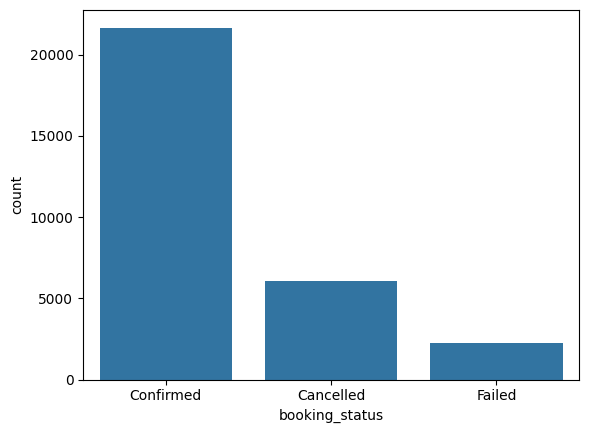

In [13]:
sns.countplot(data=df, x='booking_status')
plt.show()

In [15]:
df[date_cols].dtypes

booking_date      datetime64[ns]
check_in_date     datetime64[ns]
check_out_date    datetime64[ns]
travel_date       datetime64[ns]
dtype: object

In [18]:
# Missing values
df.isnull().sum()


customer_id              0
property_id              0
city                     0
star_rating              0
booking_date             0
check_in_date         5468
check_out_date        5468
room_type                0
num_rooms_booked         0
stay_type                0
booking_channel          0
booking_value            0
costprice                0
markup                   0
selling_price            0
payment_method           0
refund_status            0
refund_amount            0
channel_of_booking       0
booking_status           0
travel_date              0
cashback                 0
coupon_redeem            0
Coupon USed?             0
stay_length           5468
dtype: int64

In [17]:
# Duplicates
df.duplicated().sum()

np.int64(0)

In [19]:

# Data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_id         30000 non-null  int64         
 1   property_id         30000 non-null  int64         
 2   city                30000 non-null  object        
 3   star_rating         30000 non-null  int64         
 4   booking_date        30000 non-null  datetime64[ns]
 5   check_in_date       24532 non-null  datetime64[ns]
 6   check_out_date      24532 non-null  datetime64[ns]
 7   room_type           30000 non-null  object        
 8   num_rooms_booked    30000 non-null  int64         
 9   stay_type           30000 non-null  object        
 10  booking_channel     30000 non-null  object        
 11  booking_value       30000 non-null  float64       
 12  costprice           30000 non-null  int64         
 13  markup              30000 non-null  int64     

#Exporting the Cleaned version 

In [14]:
df.to_csv("Hotel_bookings_cleaned.csv", index=False)